In [41]:
import pandas as pd

df = pd.read_csv('storage/vantage-pro/2025/12/2025-12-01.csv')

print(df) 

FileNotFoundError: [Errno 2] No such file or directory: 'storage/vantage-pro/2025/12/2025-12-01.csv'

In [24]:
import pandas as pd
import glob
import os

# Percorso principale
base_path = "storage/vantage-pro/2025"

# Trova tutte le cartelle dei mesi
month_folders = sorted(glob.glob(os.path.join(base_path, "*")))

all_dfs = []

for month_folder in month_folders:
    # Trova tutti i file CSV in questa cartella
    csv_files = sorted(glob.glob(os.path.join(month_folder, "*.csv")))
    
    for csv_file in csv_files:
        # Leggi il CSV
        df = pd.read_csv(csv_file)
        all_dfs.append(df)

# Unisci tutti i DataFrame in uno solo
full_df = pd.concat(all_dfs, ignore_index=True)

# Ordina per Datetime
full_df = full_df.sort_values('Datetime').reset_index(drop=True)

print("Dataset unificato pronto!")
print(f"Numero totale di righe: {len(full_df)}")
print(f"Numero di colonne: {len(full_df.columns)}")

# --- STATISTICHE ---
print("\n--- Statistiche generali ---")
print(full_df.describe())

# Conteggio dei valori di pioggia
print("\nConteggio valori di RainRate:")
print(full_df['RainRate'].value_counts())

# Media e deviazione standard della pioggia per giorno
# full_df['Date'] = full_df['Datetime'].dt.date
# rain_daily = full_df.groupby('Date')['RainRate'].agg(['mean', 'std', 'sum'])
# print("\nMedia e deviazione standard di RainRate per giorno:")
# print(rain_daily.head())

# Eventuale percentuale di righe senza pioggia
no_rain_pct = (full_df['RainRate'] == 0).mean() * 100
print(f"\nPercentuale di righe senza pioggia: {no_rain_pct:.2f}%")






Dataset unificato pronto!
Numero totale di righe: 2674194
Numero di colonne: 59

--- Statistiche generali ---
          Barometer        TempIn         HumIn       TempOut     WindSpeed  \
count  2.615764e+06  2.615764e+06  2.615764e+06  2.615764e+06  2.615764e+06   
mean   2.997282e+01  7.831816e+01  4.718544e+01  4.464076e+02  3.235148e+01   
std    5.915187e-01  7.690758e+00  8.309090e+00  1.037752e+03  8.153274e+01   
min    0.000000e+00  2.306212e+00  1.567179e+00  1.156684e+00  0.000000e+00   
25%    2.986100e+01  7.290000e+01  4.200000e+01  5.800000e+01  0.000000e+00   
50%    2.996000e+01  7.730000e+01  4.800000e+01  6.690000e+01  2.000000e+00   
75%    3.005500e+01  8.200000e+01  5.300000e+01  7.930000e+01  5.000000e+00   
max    9.450000e+01  1.963486e+02  9.102128e+01  3.276700e+03  2.550000e+02   

            WindDir        HumOut      RainRate            UV      SolarRad  \
count  2.615764e+06  2.615764e+06  2.615764e+06  2.615764e+06  2.615764e+06   
mean   3.974399e+03 

In [25]:
# Dataset con pioggia
df_rain = full_df[full_df['RainRate'] > 0].reset_index(drop=True)

# Dataset senza pioggia
df_no_rain = full_df[full_df['RainRate'] == 0].reset_index(drop=True)

print(f"Righe con pioggia: {len(df_rain)}")
print(f"Righe senza pioggia: {len(df_no_rain)}")

# Controllo statistico rapido
print("\nStatistiche RainRate (con pioggia):")
print(df_rain['RainRate'].describe())

print("\nStatistiche RainRate (senza pioggia):")
print(df_no_rain['RainRate'].describe())

Righe con pioggia: 362731
Righe senza pioggia: 2253033

Statistiche RainRate (con pioggia):
count    362731.000000
mean        558.645559
std         232.315102
min           0.040000
25%         655.350000
50%         655.350000
75%         655.350000
max         655.350000
Name: RainRate, dtype: float64

Statistiche RainRate (senza pioggia):
count    2253033.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
Name: RainRate, dtype: float64


Intervallo medio tra misure contigue: 0 days 00:00:11
Intervallo minimo: 0 days 00:00:10
Intervallo massimo: 0 days 00:12:48


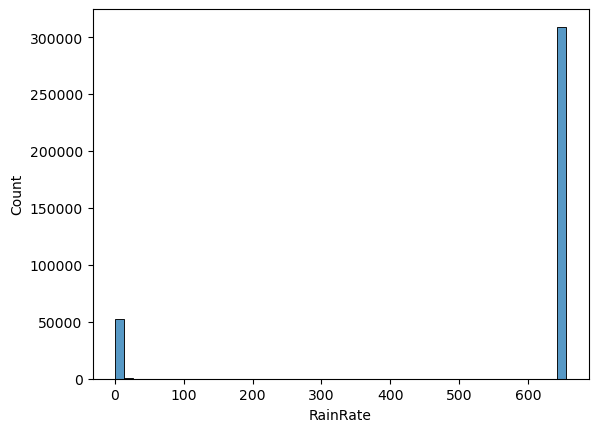

count    362731.000000
mean        558.645559
std         232.315102
min           0.040000
25%         655.350000
50%         655.350000
75%         655.350000
max         655.350000
Name: RainRate, dtype: float64


In [26]:
df_rain['Datetime'] = pd.to_datetime(full_df['Datetime'])

# Differenze tra misure contigue
df_rain = df_rain.sort_values('Datetime').reset_index(drop=True)
df_rain['delta'] = df_rain['Datetime'].diff()

print("Intervallo medio tra misure contigue:", df_rain['delta'].median())
print("Intervallo minimo:", df_rain['delta'].min())
print("Intervallo massimo:", df_rain['delta'].max())


import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(df_rain['RainRate'], bins=50)
plt.show()

print(df_rain['RainRate'].describe())


# Assicurati che Datetime sia in formato datetime
df_rain['Datetime'] = pd.to_datetime(df_rain['Datetime'])




In [37]:
df_rain['Datetime'] = pd.to_datetime(df_rain['Datetime'])
df_rain = df_rain.sort_values('Datetime').reset_index(drop=True)

# # Downsampling: prendi 1 riga ogni 60 step (10 minuti)
downsample_factor = 60  # 10 minuti / 10 secondi = 60
df_10min = df_rain.iloc[::downsample_factor].reset_index(drop=True)

print(f"Numero di righe dopo downsampling: {len(df_10min)}")



Numero di righe dopo downsampling: 6046
Datetime                  0
BarTrend                  0
Barometer                 0
TempIn                    0
HumIn                     0
TempOut                   0
WindSpeed                 0
WindSpeed10Min            0
WindDir                   0
HumOut                    0
RainRate                  0
UV                        0
SolarRad                  0
RainStorm                 0
StormStartDate            0
RainDay                   0
RainMonth                 0
RainYear                  0
ETDay                     0
ETMonth                   0
ETYear                    0
BatteryStatus            13
BatteryVolts             13
ForecastIcon             13
ForecastRuleNo           13
SunRise                  13
SunSet                   13
DatetimeWS               13
place                    13
hum                     419
pm_10_3_hour            419
pm_10_24_hour           419
pm_2p5_1_hour           419
aqi_nowcast_val         419
aqi_type

In [40]:
import torch
from torch.utils.data import Dataset



class WeatherDataset(Dataset):
    def __init__(self, df, input_window, output_window, feature_cols, target_col="RainRate"):
        """
        df: DataFrame già downsampled ogni 10 minuti
        input_window: numero di step di input (es. 6 = 1 ora di storico)
        output_window: numero di step di output (es. 6 = prossima ora da predire)
        feature_cols: lista di colonne da usare come input
        target_col: colonna target da predire
        """
        self.df = df.copy()
        self.input_window = input_window
        self.output_window = output_window
        self.feature_cols = feature_cols
        self.target_col = target_col

        # Array numpy con tutte le feature + target
        self.data = df[feature_cols + [target_col]].values

        # Indici validi per le finestre
        self.valid_indices = [
            i for i in range(len(self.data) - input_window - output_window + 1)
        ]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        i = self.valid_indices[idx]
        # Input: [input_window, n_features]
        x = self.data[i:i+self.input_window, :-1]
        # Output: [output_window, 1]
        y = self.data[i+self.input_window:i+self.input_window+self.output_window, -1:]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

    

# Seleziona tutte le colonne numeriche tranne il target
feature_cols = ["Barometer","TempIn","HumIn","TempOut","WindSpeed","WindDir","HumOut"]

input_window = 12    # 1 ora di storico
output_window = 6   # prossima ora da predire

dataset = WeatherDataset(df_10min, input_window, output_window, feature_cols)

x, y = dataset[0]
print("Feature usate:", dataset.feature_cols)
print("Shape input:", x.shape)   # [input_window, n_features]
print("Shape target:", y.shape)  # [output_window, 1]

from torch.utils.data import DataLoader
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

dataset[0]

import torch

# Conta i NaN in tutto il dataset
nan_count = torch.isnan(torch.tensor(dataset.data)).sum().item()
print(f"Totale valori NaN nel dataset: {nan_count}")

# Conta NaN per colonna
nan_per_col = torch.isnan(torch.tensor(dataset.data)).sum(dim=0)
for col, n in zip(dataset.feature_cols + ["RainRate"], nan_per_col):
    print(f"{col}: {n.item()} NaN")


Feature usate: ['Barometer', 'TempIn', 'HumIn', 'TempOut', 'WindSpeed', 'WindDir', 'HumOut']
Shape input: torch.Size([12, 7])
Shape target: torch.Size([6, 1])
Totale valori NaN nel dataset: 0
Barometer: 0 NaN
TempIn: 0 NaN
HumIn: 0 NaN
TempOut: 0 NaN
WindSpeed: 0 NaN
WindDir: 0 NaN
HumOut: 0 NaN
RainRate: 0 NaN
